# Catalogue des ablations

Ce notebook montre l'effet visuel de chaque ablation (A1-A7) telle qu'elle
est reellement executee par le pipeline d'entrainement (`src/chain.py`) —
pas une reimplementation separee pour le notebook. Chaque section rejoue la
chaine canonique du protocole (§2) sur le meme oiseau et le meme sac de
crops, en n'activant qu'une ablation a la fois (ou une combinaison, en fin
de notebook), pour que les panneaux soient directement comparables — comme
la figure 2 du protocole.

Chaque section affiche aussi le temps mesure pour ce sac
(`meta["timings"]`, chronometre directement dans `chain.build_bag()`) : le
temps total, et le cout specifique de l'ablation active quand il y en a un
(`read_source_s` pour A1/A2/A7 - ce sont des lectures de cache qui
remplacent la lecture de la source, pas des calculs a part - `A3_s`/`A4_s`/
`A5_s`/`A6_s` sinon). Pour une comparaison chronometree plus systematique
(plusieurs specimens, repetitions), voir `scripts/benchmark_ablations.py` -
ce notebook montre juste, panneau par panneau, ce que chaque ablation coute
sur ce sac precis.


In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import yaml

from pathlib import Path

from src.chain import build_bag
from src.rng import derive_rng
from src.ablations.common import Condition
from src.ablations import a3_block_permutation, a4_directional_blur, a5_spectral_slope, a6_colour_removal
from src.ablations.combinations import all_admissible_conditions, marginal_inclusion_probabilities, K_PROBABILITIES
from src import npy_io, color

with open("../configs/paths.yaml") as f:
    paths_cfg = yaml.safe_load(f)

DATASET_DIR = Path(paths_cfg["dataset_dir"])
DATASET_A1_DIR = Path(paths_cfg["dataset_a1_dir"])
DATASET_A2_DIR = Path(paths_cfg["dataset_a2_dir"])
DATASET_A7_DIR = Path(paths_cfg["dataset_a7_dir"])
DATASET_A6_CLASS_DIR = Path(paths_cfg["dataset_a6_classification_dir"])

# a specimen that already has an A2 cache entry built (scripts/build_a2_cache.py
# was run once on the first few specimens while developing this project) —
# pick a different stem here if you've built the full A2 cache and want a
# more colourful bird.
STEM = "Abeillia_abeillei_1_M_Back_Vis_G199130"

# same geometry (flip + the 16 crop positions) for every condition shown
# below, so panels are directly comparable — exactly the mechanism
# evaluate.py uses for the same reason (protocole §7).
GEOMETRY_RNG_SEED = ("notebook-demo", STEM)

# which crop in the (16, 224, 224, 3) bag to display: index 8 is the first
# native-224 crop (indices 0-7 are the 128px crops, resized up and visibly
# softer — see chain.CROP_SIZES).
DISPLAY_CROP_INDEX = 8


def build(codes=(), **fixed):
    condition = Condition(active=frozenset(codes))
    rng = derive_rng("notebook-condition", STEM, condition, fixed)
    geometry_rng = derive_rng(*GEOMETRY_RNG_SEED)
    bag, meta = build_bag(
        DATASET_DIR, DATASET_A1_DIR, DATASET_A2_DIR, DATASET_A7_DIR, STEM, condition, rng,
        positions_rng=geometry_rng, dataset_a6_class_dir=DATASET_A6_CLASS_DIR, **fixed
    )
    return bag, meta


def show(panels, suptitle=None, figsize_per_panel=2.6):
    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_panel * n, figsize_per_panel + 0.6))
    if n == 1:
        axes = [axes]
    for ax, (title, crop) in zip(axes, panels):
        ax.imshow(crop)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()


def print_timings(label, meta, highlight=None):
    """meta["timings"] (chain.build_bag()) always has total_s; highlight
    names one or more of its other keys to call out alongside it - keys
    that don't apply to this sac (an ablation that wasn't drawn, or A1/A2/A7
    which fold into read_source_s instead of their own key) are skipped
    rather than KeyError'd, since which keys exist depends on the condition."""
    timings = meta["timings"]
    parts = [f"total={timings['total_s']:.3f}s"]
    keys = [highlight] if isinstance(highlight, str) else (highlight or [])
    for key in keys:
        if key in timings:
            parts.append(f"{key}={timings[key]:.3f}s")
    print(f"[{label}] " + "  ".join(parts))


## L'oiseau de demonstration, et le sac de reference

Le crop affiche est toujours le meme (`DISPLAY_CROP_INDEX = 8`, le premier
crop 224 natif) sur le meme sac — seule la condition change d'un panneau a
l'autre.


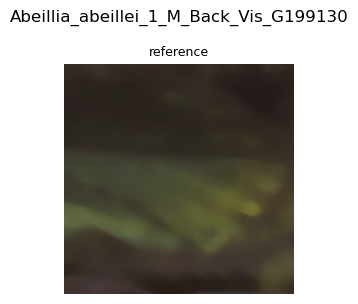

flip: True
positions (size, y, x) for the displayed crop: (224, 893, 1733)
[reference] total=0.698s


In [2]:
reference_bag, reference_meta = build()
show([("reference", reference_bag[DISPLAY_CROP_INDEX])], suptitle=STEM)
print("flip:", reference_meta["flip"])
print("positions (size, y, x) for the displayed crop:", reference_meta["positions"][DISPLAY_CROP_INDEX])
print_timings("reference", reference_meta)


## A1 — gris, L* conserve, et A7 — chromaticite seule, L* fixe

A1 et A7 sont les deux moities complementaires de la meme decomposition
CIELAB (protocole §3) : A1 retire la couleur et garde la clarte, A7 fait
l'inverse.


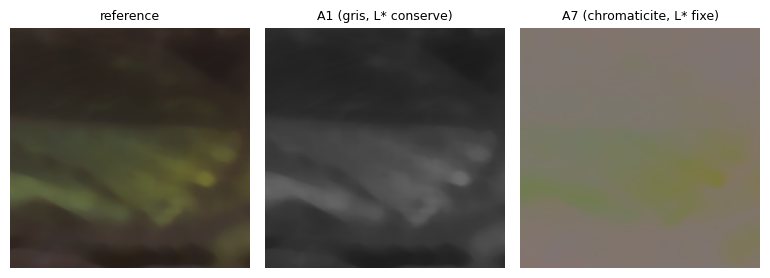

[A1] total=0.730s  read_source_s=0.305s
[A7] total=0.615s  read_source_s=0.337s
A7 gamut/roundtrip (scripts/build_a7_cache.py, runs/a7_gamut_metadata/Back.csv): mean chroma retention 0.9995  fraction of pixels with delta E > 1: 0.0047


In [3]:
a1_bag, a1_meta = build(codes=("A1",))
a7_bag, a7_meta = build(codes=("A7",))

show(
    [
        ("reference", reference_bag[DISPLAY_CROP_INDEX]),
        ("A1 (gris, L* conserve)", a1_bag[DISPLAY_CROP_INDEX]),
        ("A7 (chromaticite, L* fixe)", a7_bag[DISPLAY_CROP_INDEX]),
    ]
)
print_timings("A1", a1_meta, "read_source_s")
print_timings("A7", a7_meta, "read_source_s")

# A7 is a cache read (scripts/build_a7_cache.py) - no live gamut metadata to
# attach at read time, so it's not in a7_meta. That metadata lives in the
# offline build's own CSV instead, one row per specimen.
import csv

gamut_csv = Path(paths_cfg["runs_dir"]) / "a7_gamut_metadata" / "Back.csv"
row = None
if gamut_csv.exists():
    with open(gamut_csv) as f:
        row = next((r for r in csv.DictReader(f) if r["stem"] == STEM), None)

if row is not None:
    print(
        "A7 gamut/roundtrip (scripts/build_a7_cache.py, runs/a7_gamut_metadata/Back.csv): "
        f"mean chroma retention {float(row['mean_chroma_retention_ratio']):.4f}"
        f"  fraction of pixels with delta E > 1: {float(row['fraction_pixels_delta_E_gt_1']):.4f}"
    )
else:
    print(f"no A7 gamut metadata row for {STEM} in {gamut_csv} - run scripts/build_a7_cache.py for this specimen")


## A2 — gris + niveau et contraste standardises

Contrairement aux autres, A2 n'est pas calculee ici : elle est lue dans le
cache hors-ligne construit par `scripts/build_a2_cache.py`. Si ce cache
n'existe pas encore pour `STEM`, la cellule ci-dessous l'indique clairement
plutot que de planter silencieusement.


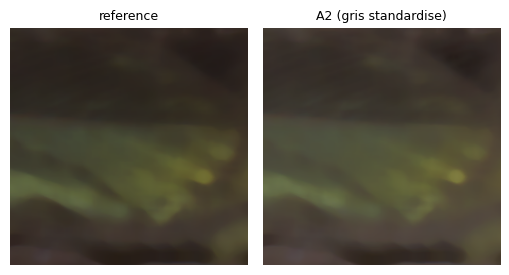

[A2] total=0.488s  read_source_s=0.287s


In [4]:
try:
    a2_bag, a2_meta = build(codes=("A2",))
    show([("reference", reference_bag[DISPLAY_CROP_INDEX]), ("A2 (gris standardise)", a2_bag[DISPLAY_CROP_INDEX])])
    print_timings("A2", a2_meta, "read_source_s")
except FileNotFoundError as e:
    print(e)


## A6 — retrait d'une couleur

La categorie est tiree parmi celles presentes sur l'oiseau entier (protocole
§3) ; on affiche ici les deux plus etendues, comme la figure 2 du protocole.

`classify_delhey_rgb` a longtemps ete l'operation la plus lente du projet
(~12s/oiseau, tombe a ~4-5s apres l'avoir restreinte a la bounding box du
masque). Depuis, `scripts/build_a6_classification_cache.py` precalcule cette
classification une fois par specimen (voir `a6_colour_removal.
build_classification()`) ; quand ce cache existe pour `STEM` (et que le
cache A1 existe aussi — la version niveaux de gris sert de source pour les
pixels retires, voir `apply_from_cache()`), `chain.build_bag()` l'utilise
au lieu de reclassifier en ligne, avec retour silencieux sur la
classification en ligne sinon. La cellule ci-dessous ne prend donc plus une
grosse dizaine de secondes si le cache est pret pour `STEM`.

chromatic categories present on this specimen: ['blue', 'purple', 'red', 'yellow', 'green', 'rufous', 'light_brown', 'dark_brown']


[A6 (blue)] total=0.533s  A6_s=0.258s


[A6 (purple)] total=0.360s  A6_s=0.082s


[A6 (red)] total=0.337s  A6_s=0.068s


[A6 (yellow)] total=0.374s  A6_s=0.081s


[A6 (green)] total=0.367s  A6_s=0.094s


[A6 (rufous)] total=0.409s  A6_s=0.103s


[A6 (light_brown)] total=0.356s  A6_s=0.073s


[A6 (dark_brown)] total=0.385s  A6_s=0.100s


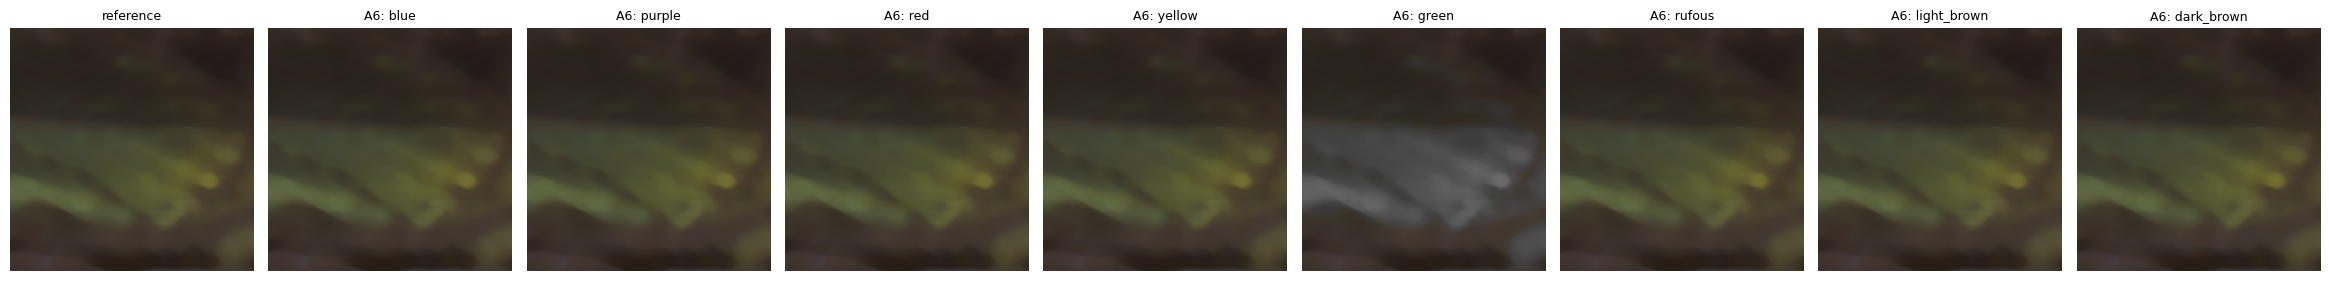

A6 source for the last panel above: precomputed_classification_and_A1_cache


In [5]:
canvas = npy_io.read_canvas(DATASET_DIR, STEM)
mask = npy_io.foreground_mask(canvas)
present = a6_colour_removal.categories_present(canvas, mask)
print("chromatic categories present on this specimen:", present)

panels = [("reference", reference_bag[DISPLAY_CROP_INDEX])]
for category in present:
    bag, meta = build(codes=("A6",), fixed_a6_category=category)
    panels.append((f"A6: {category}", bag[DISPLAY_CROP_INDEX]))
    print_timings(f"A6 ({category})", meta, "A6_s")
show(panels)

print("A6 source for the last panel above:", meta["A6"].get("source", "online (classifier)"))


### Ce que les deux optimisations A6 ont change

`draw_and_apply` (utilise par `chain.py` quand le cache est absent) classifie
l'oiseau **une seule fois** et reutilise ce resultat pour choisir la
categorie *et* la retirer — au lieu de classifier deux fois separement
(une fois pour savoir quelles couleurs sont presentes via
`categories_present`, une deuxieme fois a l'interieur de l'ablation).

`draw_and_apply_from_cache` va plus loin : quand la classification est deja
sur disque (`scripts/build_a6_classification_cache.py`), il n'y a plus
aucune classification a faire du tout, en ligne ou non — juste deux lectures
de cache (labels + image A1 en niveaux de gris) et une selection de pixels
(`apply_from_cache()`). La cellule ci-dessous chronometre les trois
approches sur le meme oiseau (le cache existe pour `STEM` sur cette
machine).

In [6]:
import time

rng = derive_rng("notebook-a6-timing", STEM)

t0 = time.perf_counter()
present_for_timing = a6_colour_removal.categories_present(canvas, mask)
category_for_timing = present_for_timing[0]
color.ablate_delhey_colour(
    canvas.astype(np.float64) / 255.0, category=category_for_timing, foreground=mask, strength=1.0
)
t_separate = time.perf_counter() - t0

t0 = time.perf_counter()
a6_colour_removal.draw_and_apply(canvas, mask, rng)
t_fused = time.perf_counter() - t0

from src.ablations import a1_gray_lstar

t_cached = None
try:
    labels = a6_colour_removal.read_classification_cache_entry(DATASET_A6_CLASS_DIR, STEM)
    grayscale = a1_gray_lstar.read_canvas(DATASET_A1_DIR, STEM)
except FileNotFoundError:
    labels = grayscale = None

if labels is not None:
    t0 = time.perf_counter()
    a6_colour_removal.draw_and_apply_from_cache(canvas, mask, labels, grayscale, rng)
    t_cached = time.perf_counter() - t0

print(f"deux classifications separees      : {t_separate:.2f}s")
print(f"une seule (draw_and_apply, en ligne): {t_fused:.2f}s")
if t_cached is not None:
    print(f"depuis le cache (aucune classif.)   : {t_cached:.3f}s")
else:
    print("cache absent pour ce STEM sur cette machine — pas de comparaison a trois")


deux classifications separees      : 57.21s
une seule (draw_and_apply, en ligne): 44.05s
depuis le cache (aucune classif.)   : 0.158s


## A3 — permutation de blocs

Les quatre cotes evalues par le protocole (§7) : du plus grossier (56px) a
la permutation pixel-a-pixel (1px), qui ne conserve que l'histogramme.


[A3 (h=1px)] total=0.369s  A3_s=0.031s


[A3 (h=7px)] total=0.294s  A3_s=0.005s


[A3 (h=16px)] total=0.284s  A3_s=0.004s


[A3 (h=56px)] total=0.272s  A3_s=0.003s


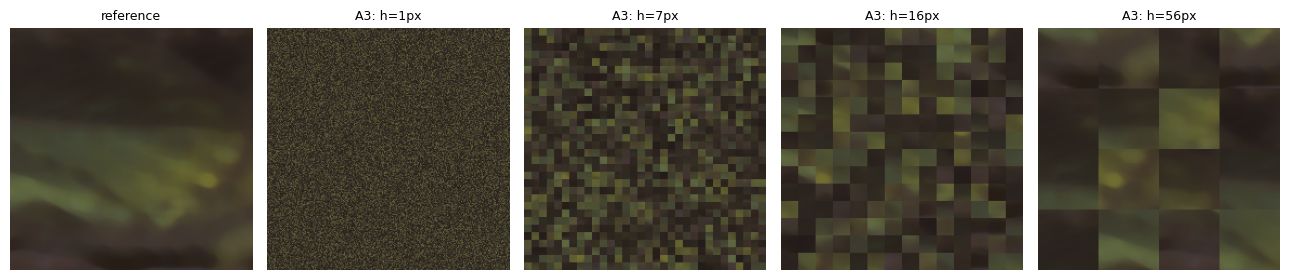

In [7]:
panels = [("reference", reference_bag[DISPLAY_CROP_INDEX])]
for h in a3_block_permutation.SIDE_CHOICES[::3]:  # a spread across the grid, not all ten
    bag, meta = build(codes=("A3",), fixed_a3_side=h)
    panels.append((f"A3: h={h}px", bag[DISPLAY_CROP_INDEX]))
    print_timings(f"A3 (h={h}px)", meta, "A3_s")
show(panels)


## A4 — flou directionnel

Les quatre coins de l'espace des parametres (protocole §3/figure 2) :
theta in {0, 90} x L in {17, 101}, les deux bornes de la loi log-uniforme.


[A4 (theta=0, L=17)] total=0.329s  A4_s=0.007s


[A4 (theta=0, L=101)] total=0.356s  A4_s=0.039s


[A4 (theta=90, L=17)] total=0.264s  A4_s=0.006s


[A4 (theta=90, L=101)] total=0.331s  A4_s=0.043s


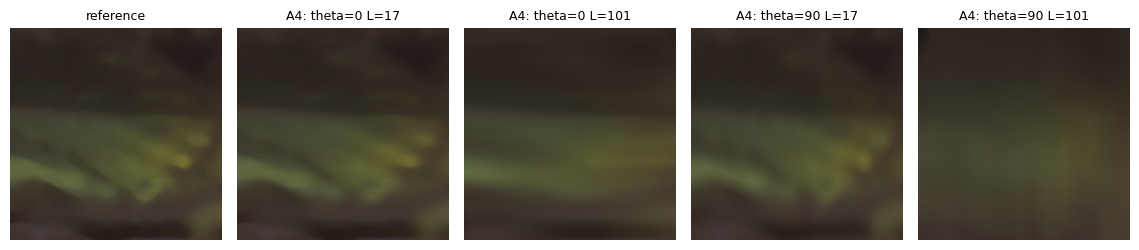

In [8]:
panels = [("reference", reference_bag[DISPLAY_CROP_INDEX])]
for theta in (0, 90):
    for length in (17, 101):
        bag, meta = build(codes=("A4",), fixed_a4_params={"theta": theta, "length": length})
        panels.append((f"A4: theta={theta} L={length}", bag[DISPLAY_CROP_INDEX]))
        print_timings(f"A4 (theta={theta}, L={length})", meta, "A4_s")
show(panels, figsize_per_panel=2.3)


## A5 — pente du spectre de Fourier

Le crop est regrade vers une pente cible tiree autour de la valeur mesuree
par le protocole (`a5_spectral_slope.TARGET_ALPHA_224` pour un crop 224
natif) avec un jitter de +/- `a5_spectral_slope.ALPHA_JITTER`, tire a
nouveau a chaque crop plutot que fixe — voir le docstring du module pour
pourquoi (un residu fixe entre la pente obtenue et une cible fixe serait un
signal reproductible, potentiellement correle a la classe ; le jitter le
decorrele du contenu de l'image). La metadonnee rapporte la pente mesuree
avant/apres le regrade et la cible reellement tiree pour ce crop.

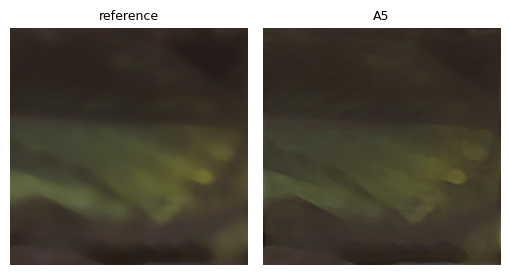

reference target (224px): 1.49  +/- 0.1
alpha before: 1.25  ->  after: 1.42  (drawn target: 1.417)
[A5] total=0.818s  A5_s=0.530s

drawn target across 3 independent draws (same crop size):
  1.395
  1.489
  1.532


In [9]:
a5_bag, a5_meta = build(codes=("A5",))
show([("reference", reference_bag[DISPLAY_CROP_INDEX]), ("A5", a5_bag[DISPLAY_CROP_INDEX])])

a5_crop_meta = a5_meta["crops"][DISPLAY_CROP_INDEX]["A5"]
print(f"reference target (224px): {a5_spectral_slope.TARGET_ALPHA_224}  +/- {a5_spectral_slope.ALPHA_JITTER}")
print(f"alpha before: {a5_crop_meta['alpha_before']:.2f}  ->  after: {a5_crop_meta['alpha_after']:.2f}  (drawn target: {a5_crop_meta['target_alpha']:.3f})")
print_timings("A5", a5_meta, "A5_s")

# same crop, three fresh draws — the drawn target moves each time, not fixed
print("\ndrawn target across 3 independent draws (same crop size):")
demo_rng = derive_rng("notebook-a5-jitter-demo", STEM)
for _ in range(3):
    print(" ", round(a5_spectral_slope.draw_target_alpha(224, demo_rng), 3))


## Combinaisons

Le tirage autorise jusqu'a trois ablations a la fois (protocole §4). Trois
exemples, dont la combinaison A4+A5 que le protocole discute explicitement
(A5 corrige la pente que A4 a durcie, mais ne defait pas son anisotropie).


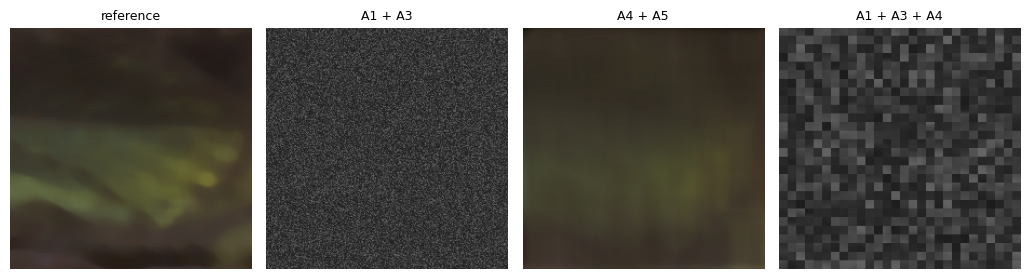

[A1+A3] total=0.271s  read_source_s=0.136s  A3_s=0.007s
[A4+A5] total=1.021s  A4_s=0.023s  A5_s=0.681s
[A1+A3+A4] total=0.281s  read_source_s=0.129s  A3_s=0.005s  A4_s=0.008s


In [10]:
combo_a1_a3, combo_a1_a3_meta = build(codes=("A1", "A3"))
combo_a4_a5, combo_a4_a5_meta = build(codes=("A4", "A5"))
combo_triple, combo_triple_meta = build(codes=("A1", "A3", "A4"))

show(
    [
        ("reference", reference_bag[DISPLAY_CROP_INDEX]),
        ("A1 + A3", combo_a1_a3[DISPLAY_CROP_INDEX]),
        ("A4 + A5", combo_a4_a5[DISPLAY_CROP_INDEX]),
        ("A1 + A3 + A4", combo_triple[DISPLAY_CROP_INDEX]),
    ]
)
print_timings("A1+A3", combo_a1_a3_meta, ["read_source_s", "A3_s"])
print_timings("A4+A5", combo_a4_a5_meta, ["A4_s", "A5_s"])
print_timings("A1+A3+A4", combo_triple_meta, ["read_source_s", "A3_s", "A4_s"])


## Verification du tirage (protocole §4)

Sanity check independant du reste du notebook : les probabilites
marginales par ablation et le nombre total de conditions admissibles
doivent reproduire exactement la table du protocole (0,140 pour les quatre
ablations CIELAB, 0,246 pour A3/A4/A5 ; 36 conditions au total).


In [11]:
conditions = all_admissible_conditions()
print("total admissible conditions:", len(conditions), "(protocole: 36)")

marginals = marginal_inclusion_probabilities()
for code_, p in sorted(marginals.items()):
    print(f"  P({code_} active) = {p:.3f}")


total admissible conditions: 36 (protocole: 36)
  P(A1 active) = 0.140
  P(A2 active) = 0.140
  P(A3 active) = 0.246
  P(A4 active) = 0.246
  P(A5 active) = 0.246
  P(A6 active) = 0.140
  P(A7 active) = 0.140
